# Partie 2 - KPI et Analyse RH

Objectif : transformer le dataset nettoye en indicateurs RH exploitables pour la decision, avec un angle turnover, engagement, carriere, remuneration et mobilite interne.


In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
add_derived_columns = utils.add_derived_columns
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
raw_df = pd.read_csv(DATA_PATH)
duplicate_employee_ids = int(raw_df["employee_id"].duplicated().sum()) if "employee_id" in raw_df.columns else 0
source_row_count = len(raw_df)
df = add_derived_columns(raw_df.drop_duplicates(subset=["employee_id"]).copy())
clean_row_count = len(df)
pd.set_option("display.max_columns", 100)


## 1. Tableau de bord KPI


In [2]:
kpi_table(df)


,KPI,Valeur
0,Effectif total,8000.00
1,Taux d'attrition (%),18.77
2,Score d'engagement moyen,67.79
3,Score de securite psychologique moyen,53.72
4,Taux de promotion sur 3 ans (%),23.88
5,Taux de mobilite interne (%),61.91
6,Heures de formation moyennes,34.47
7,Absenteisme moyen (jours),13.88
8,Heures supp. moyennes,21.06
9,Salaire moyen annuel,62314.12


## 2. Turnover

Le turnover est significatif. Il est utile de l'observer selon plusieurs segments RH pour faire ressortir les zones de vigilance et les priorites d'action.


In [3]:
display(attrition_by_group(df, "department"))
display(attrition_by_group(df, "country"))
display(attrition_by_group(df, "manager_level", ascending=True))
display(attrition_by_group(df, "salary_quartile", ascending=True))


,department,effectif,departs,attrition_rate_pct
3,HR,1033,222,21.49
2,Finance,946,195,20.61
7,Sales,1001,200,19.98
0,Customer Support,1024,194,18.95
1,Data,1039,187,18.00
4,IT,969,170,17.54
5,Marketing,972,170,17.49
6,Operations,1016,164,16.14


,country,effectif,departs,attrition_rate_pct
3,Spain,1279,257,20.09
1,France,1337,262,19.60
4,UK,1337,251,18.77
5,USA,1343,249,18.54
2,Germany,1352,244,18.05
0,Canada,1352,239,17.68


,manager_level,effectif,departs,attrition_rate_pct
1,1,1690,315,18.64
0,0,5247,986,18.79
2,2,812,153,18.84
3,3,251,48,19.12


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,salary_quartile,effectif,departs,attrition_rate_pct
3,Q4,2000,335,16.75
1,Q2,2080,385,18.51
2,Q3,1920,364,18.96
0,Q1,2000,418,20.90


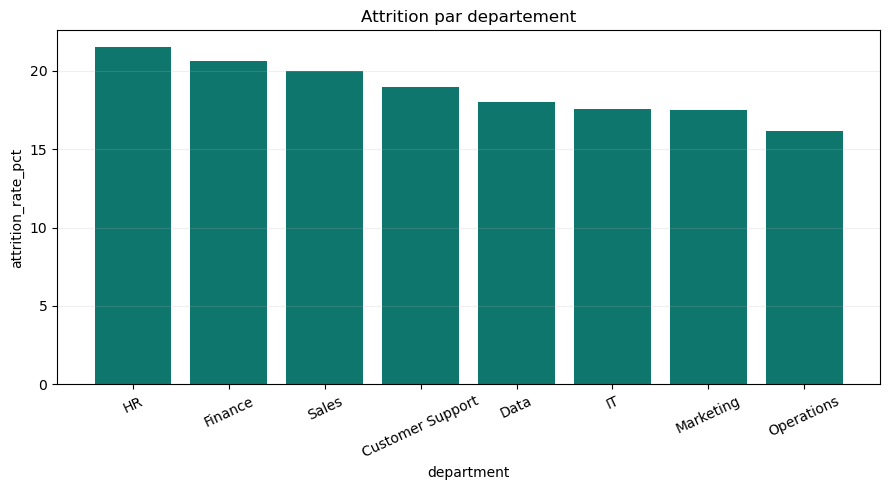

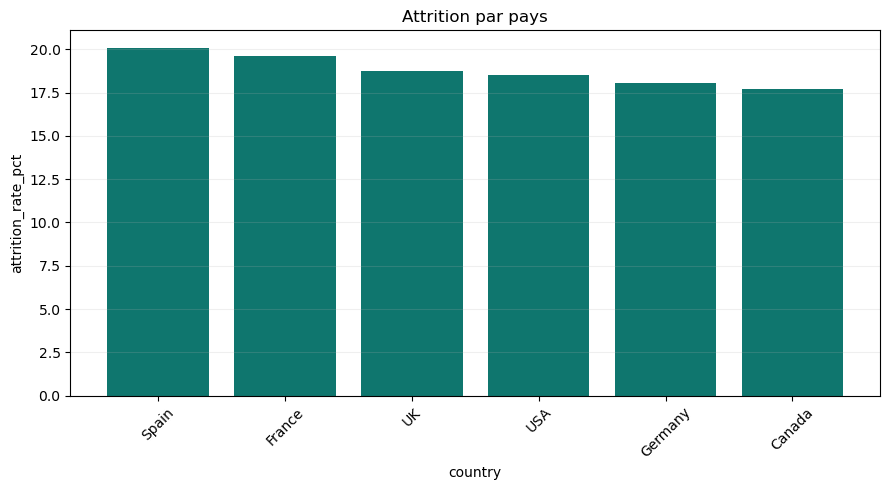

In [4]:
plot_bar(attrition_by_group(df, "department"), "department", "attrition_rate_pct", title="Attrition par departement", rotation=25)
plot_bar(attrition_by_group(df, "country"), "country", "attrition_rate_pct", title="Attrition par pays")


## 3. Engagement et conditions de travail

On relie ici l'engagement, la securite psychologique, l'absence et les heures supplementaires aux dynamiques de retention.


In [5]:
display(attrition_by_group(df, "engagement_band", ascending=True))
display(attrition_by_group(df, "overtime_band", ascending=True))
display(attrition_by_group(df, "absence_band", ascending=True))
display(average_by_group(df, "department", "engagement_score"))
display(average_by_group(df, "department", "psychological_safety_score"))


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,engagement_band,effectif,departs,attrition_rate_pct
3,Very High,1630,276,16.93
4,NaN,160,28,17.50
2,High,1827,320,17.52
1,Medium,2080,412,19.81
0,Low,2303,466,20.23


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,overtime_band,effectif,departs,attrition_rate_pct
0,0-5,845,122,14.44
1,6-15,1835,296,16.13
2,16-25,2500,448,17.92
3,26+,2820,636,22.55


C:\Users\quent\Documents\Cours\Master 2\People Analytics\Projet\hr_analysis_utils.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)


,absence_band,effectif,departs,attrition_rate_pct
1,3-5,984,18,1.83
0,0-2,236,7,2.97
2,6-10,1697,74,4.36
3,11+,5083,1403,27.60


,department,avg_engagement_score
0,HR,68.28
1,Sales,68.01
2,Data,68.01
3,Operations,67.92
4,Customer Support,67.72
5,Marketing,67.62
6,Finance,67.37
7,IT,67.33


,department,avg_psychological_safety_score
0,Finance,54.57
1,Data,53.99
2,IT,53.93
3,Marketing,53.71
4,Customer Support,53.68
5,Operations,53.66
6,Sales,53.28
7,HR,53.02


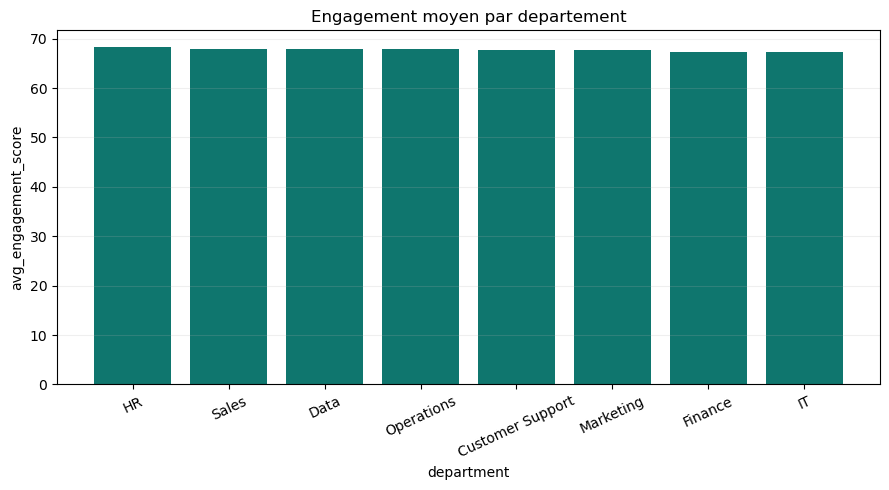

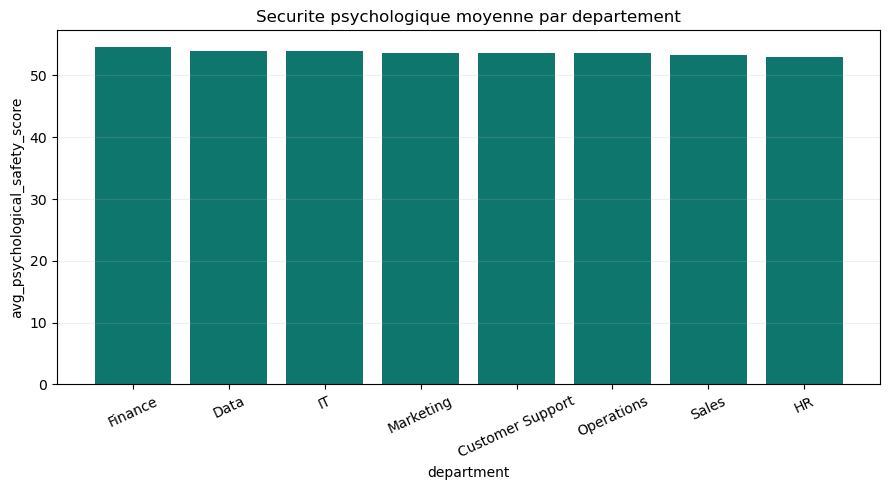

In [6]:
plot_bar(
    average_by_group(df, "department", "engagement_score"),
    "department",
    "avg_engagement_score",
    title="Engagement moyen par departement",
    rotation=25,
)
plot_bar(
    average_by_group(df, "department", "psychological_safety_score"),
    "department",
    "avg_psychological_safety_score",
    title="Securite psychologique moyenne par departement",
    rotation=25,
)


## 4. Evolution des carrieres

Cette partie met particulierement a profit les variables `years_at_company`, `internal_mobility_count` et `promotion_last_3y`, qui n'etaient pas toutes explicites dans l'enonce initial mais deviennent centrales dans le dataset actuel.


In [7]:
career_table = pd.DataFrame(
    {
        "promotion_rate_pct": df.groupby("department")["promotion_last_3y"].mean() * 100,
        "avg_training_hours": df.groupby("department")["training_hours"].mean(),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
        "avg_years_at_company": df.groupby("department")["years_at_company"].mean(),
    }
).round(2).sort_values("promotion_rate_pct", ascending=False)

career_table


,promotion_rate_pct,avg_training_hours,avg_internal_mobility,avg_years_at_company
department,,,,
Data,25.70,34.62,1.01,4.98
HR,25.27,34.86,0.93,4.96
Finance,24.21,34.65,0.97,5.31
Operations,24.21,34.30,0.97,4.89
IT,23.74,34.62,1.00,4.65
Customer Support,23.24,33.88,0.98,4.90
Marketing,22.33,34.23,1.00,5.11
Sales,22.18,34.64,0.96,5.10


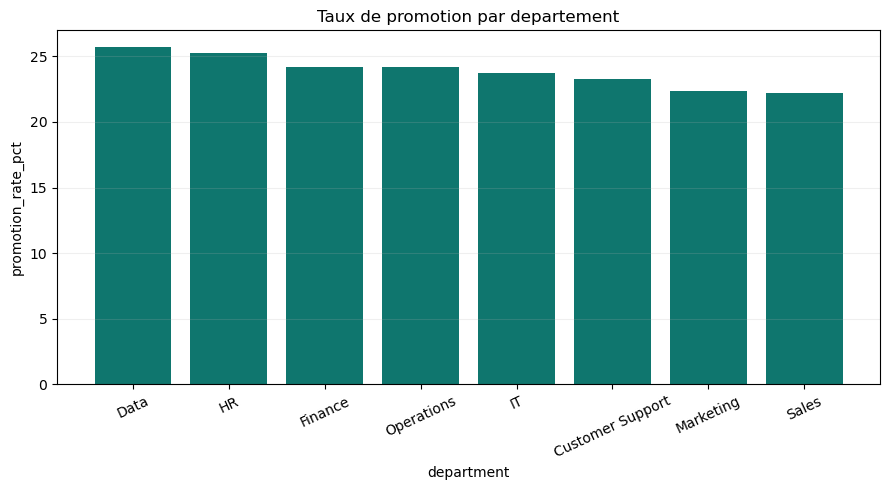

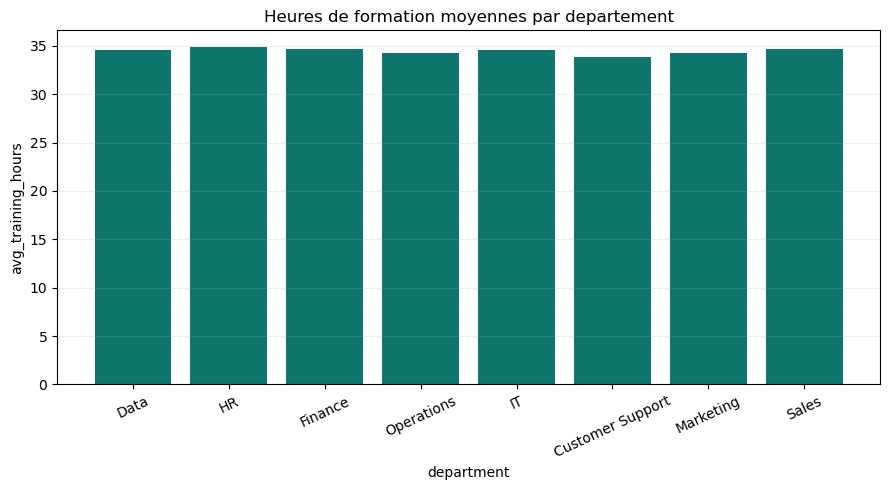

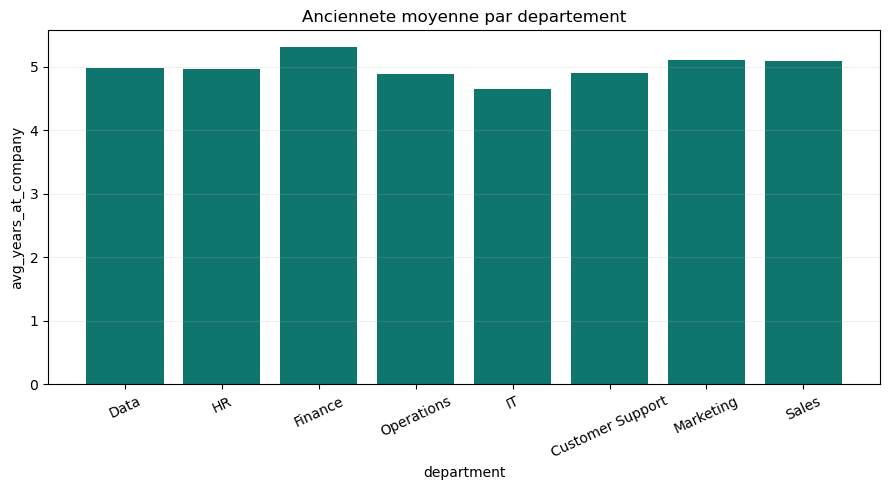

In [8]:
plot_bar(career_table.reset_index(), "department", "promotion_rate_pct", title="Taux de promotion par departement", rotation=25)
plot_bar(career_table.reset_index(), "department", "avg_training_hours", title="Heures de formation moyennes par departement", rotation=25)
plot_bar(career_table.reset_index(), "department", "avg_years_at_company", title="Anciennete moyenne par departement", rotation=25)


## 5. Structure de remuneration

Cette partie permet d'ouvrir la discussion sur les niveaux de salaire, la progression par niveau hierarchique et les ecarts eventuels entre groupes.


In [9]:
salary_by_manager = average_by_group(df, "manager_level", "salary").sort_values("manager_level")
salary_by_manager


,manager_level,avg_salary
3,0,56232.15
2,1,68533.37
1,2,79509.04
0,3,91088.74


In [10]:
salary_gap_by_gender(df)


,gender,avg_salary,gap_vs_male_pct
0,Female,60908.11,-4.32
1,Male,63656.89,0.00
2,Non-Binary,63220.81,-0.69


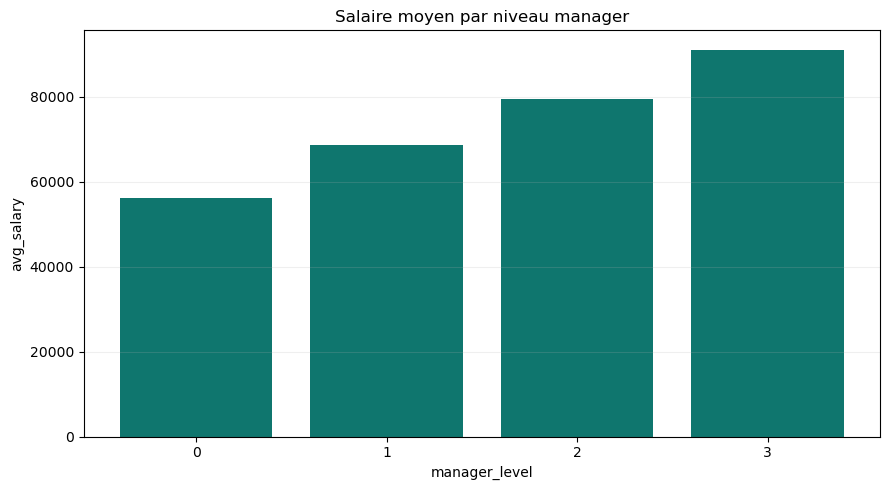

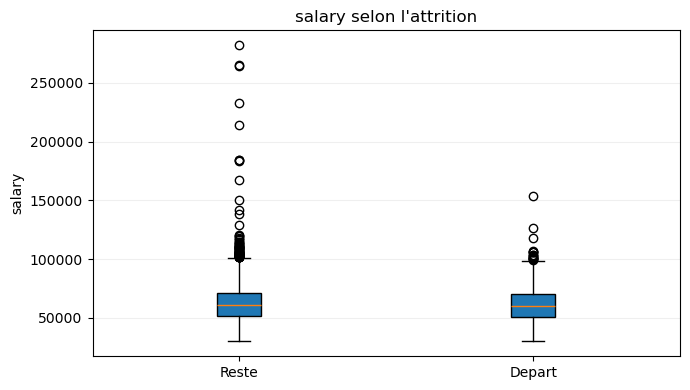

In [11]:
plot_bar(salary_by_manager, "manager_level", "avg_salary", title="Salaire moyen par niveau manager", rotation=0)
plot_box_by_attrition(df, "salary")


## 6. Mobilite interne


In [12]:
mobility_table = pd.DataFrame(
    {
        "mobility_rate_pct": df.groupby("department")["internal_mobility_count"].apply(lambda s: (s > 0).mean() * 100),
        "avg_internal_mobility": df.groupby("department")["internal_mobility_count"].mean(),
        "attrition_rate_pct": df.groupby("department")["attrition"].mean() * 100,
    }
).round(2).sort_values("mobility_rate_pct", ascending=False)

mobility_table


,mobility_rate_pct,avg_internal_mobility,attrition_rate_pct
department,,,
Data,63.33,1.01,18.00
IT,63.16,1.00,17.54
Marketing,62.86,1.00,17.49
Finance,62.16,0.97,20.61
Operations,61.71,0.97,16.14
Customer Support,61.62,0.98,18.95
Sales,61.24,0.96,19.98
HR,59.34,0.93,21.49


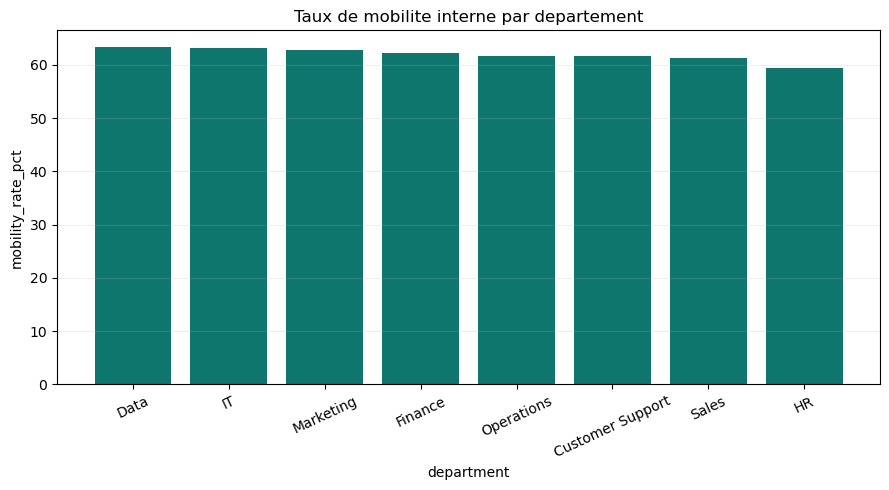

In [13]:
plot_bar(mobility_table.reset_index(), "department", "mobility_rate_pct", title="Taux de mobilite interne par departement", rotation=25)


## 7. Synthese analytique

- **Effectif analyse** : 8 000 collaborateurs uniques.
- **Attrition globale** : 18,77 %.
- **Engagement moyen** : 67,79 / 100.
- **Securite psychologique moyenne** : 53,72 / 100.
- **Promotion sur 3 ans** : 23,88 % environ.
- **Mobilite interne** : 61,91 % des collaborateurs ont connu au moins une mobilite.
- **Salaire moyen** : 62 314 environ par an.

### Points d'attention

- L'attrition est plus elevee en **Espagne**, en **France**, ainsi que dans les departements **HR**, **Finance** et **Sales**.
- Les collaborateurs avec **fort absentisme**, **heures supplementaires elevees** et **engagement plus faible** presentent davantage de risque de depart.
- Les collaborateurs partis ont en moyenne une **securite psychologique beaucoup plus basse**, **moins de mobilite interne**, **un salaire plus faible** et **moins d'anciennete**.
- L'anciennete, la promotion recente et la mobilite interne apparaissent comme des dimensions RH particulierement structurantes dans ce dataset.
- Le salaire moyen des femmes ressort a un niveau inferieur a celui des hommes dans une lecture brute du dataset. Il faudrait prolonger par une analyse controlee des postes, pays et niveaux.


## 8. Validation de KPI et signaux croises

Cette section consolide quelques hypotheses utiles au pilotage RH, en reliant plusieurs dimensions a la fois.


In [14]:
validation_table = pd.DataFrame(
    [
        ("OT x safety psychologique", "Confirme", "La safety psychologique modere fortement l'effet de la surcharge ; safety basse = attrition tres elevee meme avec OT non extreme."),
        ("Age x mobilite interne", "Confirme", "L'absence de mobilite fait monter l'attrition a plus de 30 % quel que soit l'age ; avec mobilite, elle retombe autour de 9-10 %."),
        ("Remote -> visibilite", "Confirme", "La visibilite baisse regulierement quand le remote augmente."),
        ("Parents x OT x genre", "Confirme", "Chez les parents en forte surcharge, l'attrition des femmes est environ deux fois plus elevee que celle des hommes."),
        ("Remote x engagement", "Partiel", "L'effet de l'engagement sur l'attrition est plus visible en hybride qu'en full remote."),
        ("PhD x bas salaire", "Partiel", "Le risque existe, mais il n'est pas reserve aux profils PhD."),
        ("Visibilite x mobilite", "Nuance", "La mobilite interne explique bien plus les departs que la visibilite seule."),
        ("Remote x promotion", "Nuance", "Le remote degrade la visibilite, mais l'effet sur la promotion reste limite dans ce dataset."),
    ],
    columns=["Hypothese", "Statut", "Lecture KPI"],
)

validation_table


,Hypothese,Statut,Lecture KPI
0,OT x safety psychologique,Confirme,La safety psychologique modere fortement l'eff...
1,Age x mobilite interne,Confirme,L'absence de mobilite fait monter l'attrition ...
2,Remote -> visibilite,Confirme,La visibilite baisse regulierement quand le re...
3,Parents x OT x genre,Confirme,"Chez les parents en forte surcharge, l'attriti..."
4,Remote x engagement,Partiel,L'effet de l'engagement sur l'attrition est pl...
5,PhD x bas salaire,Partiel,"Le risque existe, mais il n'est pas reserve au..."
6,Visibilite x mobilite,Nuance,La mobilite interne explique bien plus les dep...
7,Remote x promotion,Nuance,"Le remote degrade la visibilite, mais l'effet ..."


### Implications RH

- La **mobilite interne** ressort comme un levier de retention tres transversal, au-dela des differences d'age ou de visibilite.
- La **securite psychologique** doit etre suivie comme un indicateur avance de risque, en particulier dans les contextes de surcharge.
- Les analyses croisees suggerent aussi une vigilance specifique sur les **parents en forte charge de travail**, avec un possible enjeu d'equite de genre.
- La **visibilite** est un bon indicateur d'environnement de travail, mais pas un determinant direct des departs dans ce dataset.
